In [87]:
# -*- coding: utf-8 -*-
import torch
import numpy as np
import matplotlib.pyplot as plt
from core.data_generator import BrownianMotionGenerator
from core.network import FeedForwardNN as myNN
from models.radner_terminal_general_solver import RadnerEquilibriumSolver4, RadnerEquilibriumSolver_NoPhi1
from utils.visualization import RadnerVisualizer


import copy
import os
import random

def set_seed(seed=1000):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # deterministic mode
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # 强制使用 deterministic 算法
    torch.use_deterministic_algorithms(True)

    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

set_seed(100)

# -------------------------
# 1. Benchmark Nonlinear Economy: Example 4.4
# -------------------------

# Time horizon and discretization
T = 1  # Terminal time
M = 128  # Number of trajectories per batch
N = 50 # Number of time steps
D = 2  # Dimension of Brownian motion (state space)
I = 2  # Number of agents
K = 1000  # Number of validation trajectories


# Training hyperparameters
epoch = 10 # Number of training epochs
NIter = 1000  # Number of iterations per epoch
patience = 2  # Patience for early stopping


t_train, W_train = BrownianMotionGenerator.generate(M * NIter, N, D, T)

config = {
    'T': T,
    'M': M,
    'N': N,
    'D': D,
    'I': I,
    'K': K,
    'learning_rate': 1e-4,
    'device': 'cpu',
    # 'layers': [D + 1] + 5 * [256] + [(I + 1) * (1 + D)],  #NN layers
    'layers_z': [D + 1] + 5 * [256] + [(I + 1) * (D)],  #NN layers
    'layers_y': [D + 1] + 5 * [256] + [(I + 1) * 1],  #NN layers
    'drift_D': 0.0,
    'sigD': torch.tensor([[0.24/np.sqrt(2), 0.24/np.sqrt(2)]], dtype=torch.float32),  # dividend depends on W1+W2
    'muE': torch.zeros(2),
    'sigE': torch.tensor([
        [0., 0.6/np.sqrt(2)],  # Agent1 exposure to W2 (put)
        [0., 0.4/np.sqrt(2)]   # Agent2 opposite
    ], dtype=torch.float32),
    'alpha': torch.tensor([0.4, 0.6]),  # CARA risk aversion
    'epsilon': 1e-6,
    'N_option': 1,  # Number of options in the economy (for payoff construction),
    'a_expo': 0.5,  # Exponent for payoff construction (e.g., power utility)
    'x2': 0.0,  # Coefficient for W2 in payoff construction
    'checkpoint_path': 'radner_example44.pth',
    't_train': t_train,  # To be set after generating training data
    'W_train': W_train,  # To be set after generating training data
}


class RadnerEquilibriumSolver_put(RadnerEquilibriumSolver4):
    def __init__(self, config):
        """Initialize solver with configuration dictionary.
        
        Args:
            config: Dictionary containing:
                - T: Terminal time
                - M: Batch size (number of trajectories)
                - N: Number of time steps
                - D: State dimension
                - I: Number of agents
                - K: Validation set size
                - learning_rate: Learning rate for Adam
                - device: 'cpu' or 'cuda'
                - checkpoint_path: Path to save best model
        """
        super().__init__(config)
        self.x2 = config['x2']
        
    

    # def endowment_process(self, t, X, i):

        

    #     N_option = self.N_option
    #     k = self.a_expo
    #     x2 = self.x2

    #     temp = self.sigE[i,:] * (X + x2)
    #     # return torch.sum(temp, -1, keepdim = True)

    #     X2 = temp[:,1:2]  # second Brownian source
    
    #     # put_payoff = F.softplus(-X2, beta=50.0)
    #     # call_payoff = torch.clamp(X2 - k, min=0.0)
    #     # call_payoff = X2
    #     call_payoff = torch.minimum(X2, torch.zeros_like(X2))

    #     if i == 0:

    #         return -N_option * call_payoff

    #     else:

    #         return N_option * call_payoff
        

    
    def endowment_process(self, t, X, i):

        

        N_option = self.N_option
        a = self.a_expo
        x2 = self.x2

        temp = self.sigE[i,:] * (X + x2)
        # return torch.sum(temp, -1, keepdim = True)

        X2 = temp[:,1:2]   # second Brownian source
    
        # put_payoff = F.softplus(-X2, beta=50.0)
        payoff = (1- a) * X2 + a * torch.minimum(X2, torch.zeros_like(X2))
        # put_payoff = X2

        if i == 0:

            return -N_option * payoff

        else:

            return N_option * payoff
# torch.manual_seed(1000)
# solver1 = RadnerEquilibriumSolver4(config)
# params_init_1 = copy.deepcopy(solver1.model_z.state_dict())

# torch.manual_seed(1000)
# solver2 = RadnerEquilibriumSolver4(config)
# params_init_2 = copy.deepcopy(solver2.model_z.state_dict())

# for k in params_init_1:
#     print(torch.allclose(params_init_1[k], params_init_2[k]))

print("\nProblem Configuration:")
print(f"  Terminal time: {config['T']}")
print(f"  State dimension: {config['D']}")
print(f"  Number of agents: {config['I']}")
print(f"  Time steps: {config['N']}")
print(f"  Batch size: {config['M']}")
# print(f"  Network architecture: {config['layers_y']} and {config['layers_z']}")
# print(f"  Network architecture: {config['layers']}")

# Initialize solver
print("\nInitializing solver...")
# solver = RadnerEquilibriumSolver_NoPhi1(config)
# solver = RadnerEquilibriumSolver_call(config)

# print("\nStarting training...")
# solver.train(NIter, epoch, patience)     


# # Print training summary
# print("\n" + "="*60)
# print("Training Summary:")
# print("="*60)
# print(f"Best epoch: {solver.history['best_epoch'] + 1}")
# print(f"Best validation loss: {solver.history['best_val_loss']:.6f}")
# print(f"Final training loss: {solver.history['train_loss'][-1]:.6f}")
# print(f"Total training time: {solver.history['train_time']:.2f} seconds")
# print(f"Average time per epoch: {solver.history['time_per_epoch']:.2f} seconds")



import matplotlib.pyplot as plt
import torch

x_centers = [-3, -2.5, -2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5, 3]

results = {}

for center in x_centers:

    config['x2'] = center
    config['checkpoint_path'] = f'radner_x{center}.pth'

    solver = RadnerEquilibriumSolver_put(config)
    solver.train(NIter=1000, epoch=10, patience=2)

    device = config['device']

    # ===== 只算 center 点 =====
    x_local = torch.tensor([0.0]).to(device)

    x1_grid = torch.zeros_like(x_local)
    X0 = torch.stack([x1_grid, x_local], dim=1)

    t0 = torch.zeros(1,1).to(device)

    with torch.no_grad():

        Y0 = solver.net_y(t0, X0)
        Z0 = solver.net_z(t0, X0)

        for i in range(solver.I + 1):
            Z0[:, i*solver.D:(i+1)*solver.D] = (
                Z0[:, i*solver.D:(i+1)*solver.D].unsqueeze(1)
                @ solver.sig(t0, X0)
            ).squeeze()

        equity_premium = solver.phi0(t0, X0, Z0, solver.epsilon).cpu() / (6/5)

        theta = solver.theta(Y0, Z0, 1)
        theta1 = theta[0].cpu() * solver.alpha[0]
        theta2 = theta[1].cpu() * solver.alpha[1]

        volatility = torch.norm(Z0[:, :solver.D], dim=1, keepdim=True).cpu() / (6/5)

    results[center] = {
        "x": center,
        "premium": equity_premium.item(),
        "theta1": theta1.item(),
        "theta2": theta2.item(),
        "vol": volatility.item()
    }

    print(f"center {center} done")


Problem Configuration:
  Terminal time: 1
  State dimension: 2
  Number of agents: 2
  Time steps: 50
  Batch size: 128

Initializing solver...
Epoch 1
-------------------------------
Loss 200: 0.0001221441343659535, time: 20.122639209002955
Loss 400: 8.41483870317461e-06, time: 40.16412116700667
Loss 600: 4.238738711137557e-06, time: 60.2958558750106
Loss 800: 1.7581249949216726e-06, time: 80.49351470900001
Loss 1000: 5.4050669859861955e-06, time: 100.7278169170022
Validation Loss 1: 0.0000
val_loss: 0.0000, updating best_val_loss from: inf.
Epoch 2
-------------------------------
Loss 200: 3.346973471707315e-06, time: 121.28906099998858
Loss 400: 7.198063372015895e-07, time: 142.01707883400377
Loss 600: 1.0383139397163177e-06, time: 163.1587765419972
Loss 800: 6.150626745693444e-07, time: 185.7667401249928
Loss 1000: 4.879838115812163e-07, time: 206.49768466700334
Validation Loss 2: 0.0000
val_loss: 0.0000, updating best_val_loss from: 0.0000.
Epoch 3
-------------------------------

/Users/sokchak/Desktop/FBSDE_NN/radner_equilibrium_solver/radner_equilibrium_terminal_dl/radner_solver_terminal/models/radner_terminal_general_solver.py:937: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related t

Loss 200: 7.988368452060968e-05, time: 24.36236374999862
Loss 400: 5.859947486896999e-05, time: 46.39301091598463
Loss 600: 3.064066549995914e-05, time: 64.65267699997639
Loss 800: 4.365301265352173e-06, time: 83.28969574999064
Loss 1000: 8.398571480938699e-06, time: 102.53695037498255
Validation Loss 1: 0.0000
val_loss: 0.0000, updating best_val_loss from: inf.
Epoch 2
-------------------------------
Loss 200: 6.15902099525556e-05, time: 121.95806212499156
Loss 400: 4.392730261315592e-06, time: 140.6109658749774
Loss 600: 3.1904207844490884e-06, time: 159.45337874998222
Loss 800: 2.26727788685821e-05, time: 178.1268203749787
Loss 1000: 2.2724567315890454e-05, time: 197.0514170829847
Validation Loss 2: 0.0000
val_loss: 0.0000, updating best_val_loss from: 0.0000.
Epoch 3
-------------------------------
Loss 200: 5.660676379193319e-06, time: 217.96137662499677
Loss 400: 1.4387514966074377e-06, time: 237.07002533299965
Loss 600: 6.141626727185212e-06, time: 256.13385274997563
Loss 800: 4

In [133]:
x_centers = [-6, -4, -3, -2.5, -2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5, 3, 4, 6]
x_points = np.array([x for x in x_centers])
x_points = x_points * (0.2 / np.sqrt(2))




In [89]:
scale = 0.2 / np.sqrt(2)

for center, val in results.items():

    x_target = center * scale

    idx = np.argmin(np.abs(x_points - x_target))

    if abs(x_points[idx] - x_target) > 1e-6:
        print(f"Warning: center {center} not found")

    premium_points[idx] = val["premium"]
    theta1_points[idx] = val["theta1"]
    theta2_points[idx] = val["theta2"]

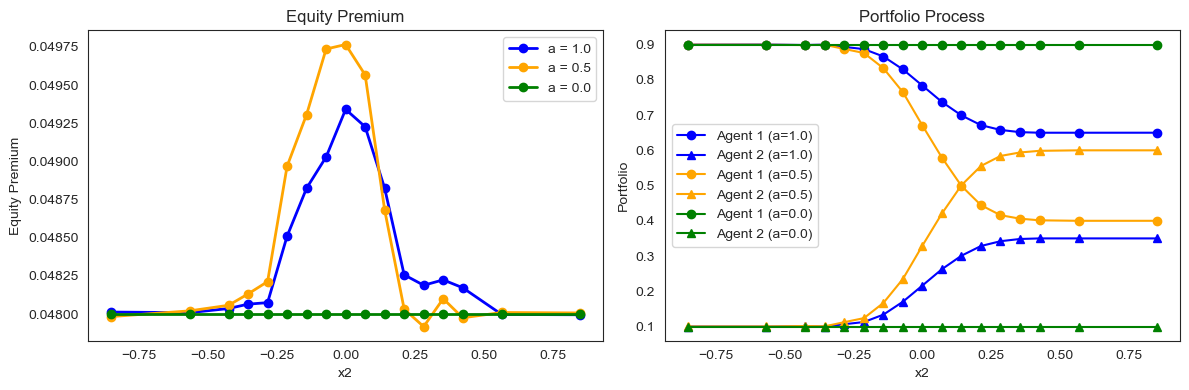

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# ===============================
# Equity Premium
# ===============================

axes[0].plot(x_points, premium_points, 'o-', linewidth=2, color='blue', label="a = 1.0")
axes[0].plot(x_points, premium_all, 'o-', linewidth=2, color='orange', label="a = 0.5")
axes[0].plot(x_points, premium_points2, 'o-', linewidth=2, color='green', label="a = 0.0")

axes[0].set_xlabel("x2")
axes[0].set_ylabel("Equity Premium")
axes[0].set_title("Equity Premium")
axes[0].legend()
# axes[0].grid(True)


# ===============================
# Portfolio Process
# ===============================

# a = 1.0
axes[1].plot(x_points, theta1_points, marker='o', linestyle='-', color='blue',
             label="Agent 1 (a=1.0)")
axes[1].plot(x_points, theta2_points, marker='^', linestyle='-', color='blue',
             label="Agent 2 (a=1.0)")

# a = 0.5
axes[1].plot(x_points, theta1_all, marker='o', linestyle='-', color='orange',
             label="Agent 1 (a=0.5)")
axes[1].plot(x_points, theta2_all, marker='^', linestyle='-', color='orange',
             label="Agent 2 (a=0.5)")

# a = 0.0
axes[1].plot(x_points, theta1_points2, marker='o', linestyle='-', color='green',
             label="Agent 1 (a=0.0)")
axes[1].plot(x_points, theta2_points2, marker='^', linestyle='-', color='green',
             label="Agent 2 (a=0.0)")


axes[1].set_xlabel("x2")
axes[1].set_ylabel("Portfolio")
axes[1].set_title("Portfolio Process")

axes[1].legend()
# axes[1].grid(True)


plt.tight_layout()
plt.show()

  step 3000/12000
  step 6000/12000
  step 9000/12000
  step 12000/12000

Saved to /mnt/user-data/outputs/fig1_N1_corrected.png
Complete: mu=0.04800, vol=0.2000
x2=0:     mu=0.04980, vol=0.2001, th1=0.6760, th2=0.3240
Crossover at x2=0.1391


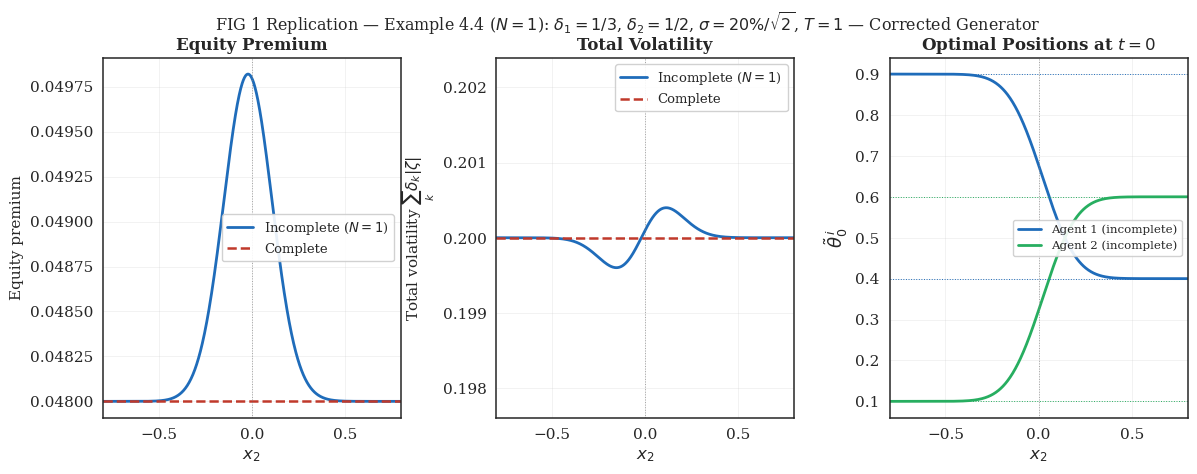

In [128]:
import numpy as np
import matplotlib.pyplot as plt

delta_1=1/3; delta_2=1/2; sum_delta=5/6
alpha_1=2/5; alpha_2=3/5
sigma_val=0.20/np.sqrt(2); N_opts=1; T=1.0
a_const=sigma_val/sum_delta

Nx=1000; Nt=12000; x2_max=1.0
dx=2*x2_max/(Nx-1); dt=T/Nt
x2=np.linspace(-x2_max,x2_max,Nx)

def grad(phi):
    u=np.empty_like(phi)
    u[1:-1]=(phi[2:]-phi[:-2])/(2*dx)
    u[0]=(-3*phi[0]+4*phi[1]-phi[2])/(2*dx)
    u[-1]=(3*phi[-1]-4*phi[-2]+phi[-3])/(2*dx)
    return u

def diffuse(phi):
    r=np.zeros_like(phi)
    r[1:-1]=sigma_val**2/2*(phi[2:]-2*phi[1:-1]+phi[:-2])/dx**2
    return r

def F0(u,p,q): 
    return -(a_const**2+sigma_val**2*u*(u+alpha_1*p+alpha_2*q))

def F1(u,p,q):
    zeta_sq = a_const**2+sigma_val**2*u**2
    numer = zeta_sq + sigma_val**2*u*alpha_2*(q-p)
    return 0.5*numer**2/zeta_sq - 0.5*sigma_val**2*p**2

def F2(u,p,q):
    zeta_sq = a_const**2+sigma_val**2*u**2
    numer = zeta_sq + sigma_val**2*u*alpha_1*(p-q)
    return 0.5*numer**2/zeta_sq - 0.5*sigma_val**2*q**2

phi0=x2/sum_delta
phi1=N_opts*np.maximum(-x2,0)/delta_1
phi2=-N_opts*np.maximum(-x2,0)/delta_2

for n in range(Nt):
    u=grad(phi0); p=grad(phi1); q=grad(phi2)
    pn0=phi0+dt*(diffuse(phi0)+F0(u,p,q))
    pn1=phi1+dt*(diffuse(phi1)+F1(u,p,q))
    pn2=phi2+dt*(diffuse(phi2)+F2(u,p,q))
    for pn in [pn0,pn1,pn2]:
        pn[0]=2*pn[1]-pn[2]; pn[-1]=2*pn[-2]-pn[-3]
    phi0,phi1,phi2=pn0,pn1,pn2
    if (n+1)%3000==0: print(f"  step {n+1}/{Nt}")

u_s=grad(phi0); p_s=grad(phi1); q_s=grad(phi2)
zeta_sq=a_const**2+sigma_val**2*u_s**2
total_vol=sum_delta*np.sqrt(zeta_sq)
eq_prem=sum_delta*(-F0(u_s,p_s,q_s))
theta1_u=alpha_1*(1+sigma_val**2*u_s*alpha_2*(q_s-p_s)/zeta_sq)
theta2_u=alpha_2*(1+sigma_val**2*u_s*alpha_1*(p_s-q_s)/zeta_sq)

mu_com=2*sigma_val**2/sum_delta; vol_com=sigma_val*np.sqrt(2)
theta1_com=alpha_1+N_opts/4; theta2_com=alpha_2-N_opts/4

# ── FIGURE ──
plt.rcParams.update({'font.family':'serif','font.size':11,'axes.linewidth':1.1})
fig, axes = plt.subplots(1,3,figsize=(14,4.8))
fig.subplots_adjust(wspace=0.32,bottom=0.13,top=0.88)

x_lo,x_hi=-0.8,0.8
mask=(x2>=x_lo)&(x2<=x_hi); xp=x2[mask]
cb='#1f6cba'; cr='#c0392b'; cg='#27ae60'; lw=2.0

# Panel 1: Equity Premium
ax=axes[0]
ax.plot(xp,eq_prem[mask],'-',color=cb,lw=lw,label=r'Incomplete ($N=1$)')
ax.axhline(mu_com,color=cr,lw=lw-0.2,ls='--',label='Complete')
ax.set_xlabel(r'$x_2$',fontsize=12); ax.set_ylabel('Equity premium',fontsize=11)
ax.set_title('Equity Premium',fontsize=12,fontweight='bold',pad=6)
ax.legend(fontsize=9.5,framealpha=0.9); ax.grid(True,alpha=0.25,lw=0.7)
ax.set_xlim(x_lo,x_hi)
ax.axvline(0,color='gray',lw=0.7,ls=':',alpha=0.7)

# Panel 2: Total Volatility
ax=axes[1]
ax.plot(xp,total_vol[mask],'-',color=cb,lw=lw,label=r'Incomplete ($N=1$)')
ax.axhline(vol_com,color=cr,lw=lw-0.2,ls='--',label='Complete')
ax.set_xlabel(r'$x_2$',fontsize=12); ax.set_ylabel(r'Total volatility $\sum_k\delta_k|\zeta|$',fontsize=11)
ax.set_title('Total Volatility',fontsize=12,fontweight='bold',pad=6)
ax.legend(fontsize=9.5,framealpha=0.9); ax.grid(True,alpha=0.25,lw=0.7)
ax.set_xlim(x_lo,x_hi)
span=max(abs(total_vol[mask]-vol_com))*6 or 0.01
ax.set_ylim(vol_com-span,vol_com+span)
ax.axvline(0,color='gray',lw=0.7,ls=':',alpha=0.7)

# Panel 3: Optimal Positions
ax=axes[2]
ax.plot(xp,theta1_u[mask],'-',color=cb, lw=lw, label=r'Agent 1 (incomplete)')
ax.plot(xp,theta2_u[mask],'-',color=cg, lw=lw, label=r'Agent 2 (incomplete)')
# ax.axhline(theta1_com,color=cb,lw=lw-0.2,ls='--',label=r'Agent 1 (complete)')
# ax.axhline(theta2_com,color=cg,lw=lw-0.2,ls='--',label=r'Agent 2 (complete)')
# Asymptotic dotted reference lines
ax.axhline(alpha_1,         color=cb,lw=0.7,ls=':')
ax.axhline(alpha_1+N_opts/2,color=cb,lw=0.7,ls=':')
ax.axhline(alpha_2,         color=cg,lw=0.7,ls=':')
ax.axhline(alpha_2-N_opts/2,color=cg,lw=0.7,ls=':')
ax.set_xlabel(r'$x_2$',fontsize=12); ax.set_ylabel(r'$\tilde\theta^{\,i}_0$',fontsize=13)
ax.set_title(r'Optimal Positions at $t=0$',fontsize=12,fontweight='bold',pad=6)
ax.legend(fontsize=8.5,framealpha=0.9,loc='right')
ax.grid(True,alpha=0.25,lw=0.7); ax.set_xlim(x_lo,x_hi)
ax.axvline(0,color='gray',lw=0.7,ls=':',alpha=0.7)

fig.suptitle(
    r'FIG 1 Replication — Example 4.4 ($N=1$): '
    r'$\delta_1=1/3$, $\delta_2=1/2$, '
    r'$\sigma=20\%/\sqrt{2}$, $T=1$ — Corrected Generator',
    fontsize=11.5
)

out = '/mnt/user-data/outputs/fig1_N1_corrected.png'
# plt.savefig(out,dpi=180,bbox_inches='tight',facecolor='white')
print(f"\nSaved to {out}")

idx0=Nx//2
print(f"Complete: mu={mu_com:.5f}, vol={vol_com:.4f}")
print(f"x2=0:     mu={eq_prem[idx0]:.5f}, vol={total_vol[idx0]:.4f}, th1={theta1_u[idx0]:.4f}, th2={theta2_u[idx0]:.4f}")
cross_idx = np.where(np.diff(np.sign(theta1_u - theta2_u)))[0]
for ci in cross_idx:
    print(f"Crossover at x2={x2[ci]:.4f}")

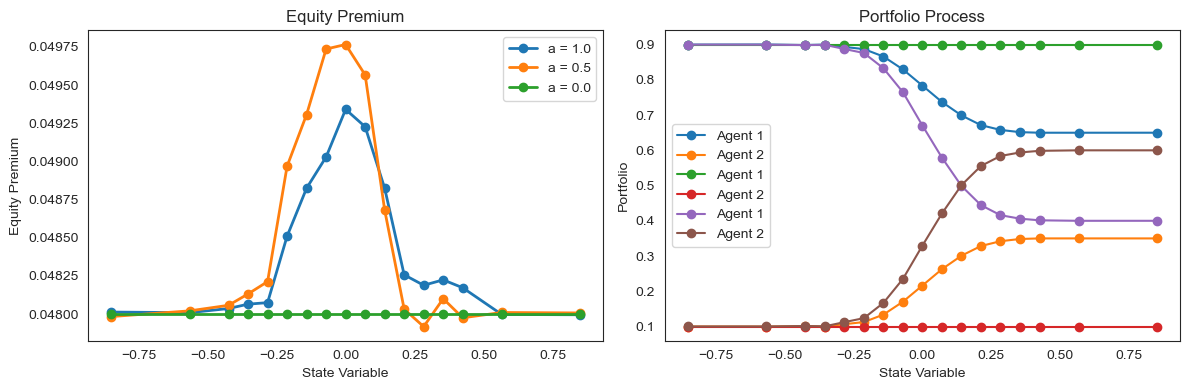

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))


# ---- Equity Premium ----
axes[0].plot(x_points, premium_points, 'o-', linewidth=2, label="a = 1.0")
axes[0].plot(x_points, premium_all, 'o-', linewidth=2, label="a = 0.5")
axes[0].plot(x_points, premium_points2, 'o-', linewidth=2, label="a = 0.0")
axes[0].set_xlabel("State Variable")
axes[0].set_ylabel("Equity Premium")
axes[0].set_title("Equity Premium")
axes[0].legend()
# axes[0].grid(True)


# ---- Portfolio Process ----
axes[1].plot(x_points, theta1_points, 'o-', label="Agent 1")
axes[1].plot(x_points, theta2_points, 'o-', label="Agent 2")
axes[1].plot(x_points, theta1_points2, 'o-', label="Agent 1")
axes[1].plot(x_points, theta2_points2, 'o-', label="Agent 2")

axes[1].plot(x_points, theta1_all, 'o-', label="Agent 1")
axes[1].plot(x_points, theta2_all, 'o-', label="Agent 2")


axes[1].set_xlabel("State Variable")
axes[1].set_ylabel("Portfolio")
axes[1].set_title("Portfolio Process")

axes[1].legend()
# axes[1].grid(True)


plt.tight_layout()
plt.show()

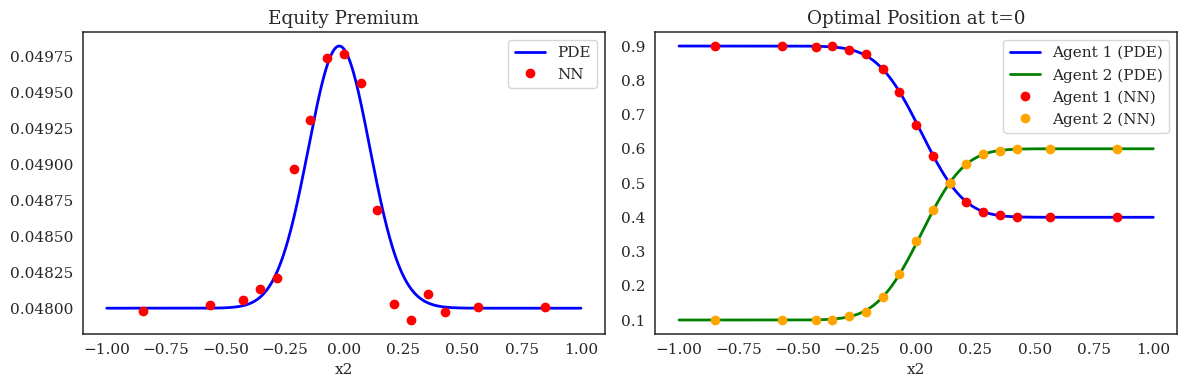

In [140]:
fig, axes = plt.subplots(1,2, figsize=(12,4))


# =========================
# Equity Premium
# =========================

# PDE (paper)
axes[0].plot(x2, eq_prem, '-', lw=2, label='PDE', color='blue')

# NN
axes[0].plot(x_points, premium_all, 'o', label='NN', color='red')

axes[0].set_xlabel("x2")
# axes[0].set_ylabel("Equity Premium")
axes[0].set_title("Equity Premium")
axes[0].legend()
# axes[0].grid(True)


# =========================
# Portfolio Process
# =========================

# PDE
axes[1].plot(x2, theta1_u, '-', lw=2, label='Agent 1 (PDE)', color='blue')
axes[1].plot(x2, theta2_u, '-', lw=2, label='Agent 2 (PDE)', color='green')

# NN
axes[1].plot(x_points, theta1_all, 'o', label='Agent 1 (NN)', color='red')
axes[1].plot(x_points, theta2_all, 'o', label='Agent 2 (NN)', color='orange')

axes[1].set_xlabel("x2")
# axes[1].set_ylabel("Position")
axes[1].set_title("Optimal Position at t=0")
axes[1].legend()
# axes[1].grid(True)


plt.tight_layout()
plt.show()

In [95]:
class RadnerEquilibriumSolver_linear(RadnerEquilibriumSolver4):
    def __init__(self, config):
        """Initialize solver with configuration dictionary.
        
        Args:
            config: Dictionary containing:
                - T: Terminal time
                - M: Batch size (number of trajectories)
                - N: Number of time steps
                - D: State dimension
                - I: Number of agents
                - K: Validation set size
                - learning_rate: Learning rate for Adam
                - device: 'cpu' or 'cuda'
                - checkpoint_path: Path to save best model
        """
        super().__init__(config)
        self.x2 = config['x2']

    def premium_exact(self): #K*1, K*D       
            """
            Compute the exact solution S(t,W) of the Radner equilibrium FBSDE.
            
            Parameters:
            t (float): time
            X (torch.tensor): Brownian motion with shape (M,N,D)
            
            Returns:
            torch.tensor: exact solution S(t,W) with shape (M,N,I)
            """
            I=self.I
            sigD=self.sigD
            temp=self.sigD
            alpha=self.alpha
            for i in range(I):
                temp=temp+alpha[i]*self.sigE[i,:]
            a=torch.sum(temp*sigD,-1,keepdims=True)
            return a


    def get_analytical_theta(self):
            """
            Analytical Radner equilibrium strategies.
            Returns:
                Tensor of shape (I,) : theta^i
            """
            b0 = self.sigD.squeeze(0)                # (D,)
            b_agents = self.sigE # (I, D)

            # numerator common term
            sum_b = b0 + (self.alpha.unsqueeze(1) * b_agents).sum(0)
            common = torch.dot(sum_b, b0)

            denom = torch.dot(b0, b0)

            theta = (common - torch.mv(b_agents, b0)) / denom
            return theta  # (I,)

In [117]:
import numpy as np

x_centers = [-6, -4, -3, -2.5, -2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5, 3, 4, 6]

results_analytical = {}


config['sigE'] =  torch.tensor([
        [0., -0.6/np.sqrt(2)],  # Agent1 exposure to W2 (put)
        [0., 0.4/np.sqrt(2)]   # Agent2 opposite
    ], dtype=torch.float32)

for center in x_centers:

    config['x2'] = center
    solver = RadnerEquilibriumSolver_linear(config)

    # analytical premium
    premium = solver.premium_exact()

    # analytical portfolio
    theta = solver.get_analytical_theta()

    results_analytical[center] = {
        "x": center,
        "premium": premium.item(),
        "theta1": theta[0].item() * solver.alpha[0],
        "theta2": theta[1].item() * solver.alpha[1]
    }

    print(f"center {center} done")


x_points2 = np.array([results_analytical[c]["x"] for c in x_centers])
premium_points2 = np.array([results_analytical[c]["premium"] for c in x_centers])/(6/5)
theta1_points2 = np.array([results_analytical[c]["theta1"] for c in x_centers]) 
theta2_points2 = np.array([results_analytical[c]["theta2"] for c in x_centers]) 

x_points2 = x_points2 * (0.2 / np.sqrt(2))

center -6 done
center -4 done
center -3 done
center -2.5 done
center -2 done
center -1.5 done
center -1 done
center -0.5 done
center 0 done
center 0.5 done
center 1 done
center 1.5 done
center 2 done
center 2.5 done
center 3 done
center 4 done
center 6 done


In [92]:
import pandas as pd

df = pd.DataFrame({
    "x": x_points,
    "premium": premium_points,
    "theta1": theta1_points,
    "theta2": theta2_points
})

df.to_csv("/Users/sokchak/Desktop/FBSDE_NN/radner_equilibrium_solver/radner_equilibrium_terminal_dl/radner_solver_terminal/radner_results_0.5.csv", index=False)

In [132]:
x_points

[]

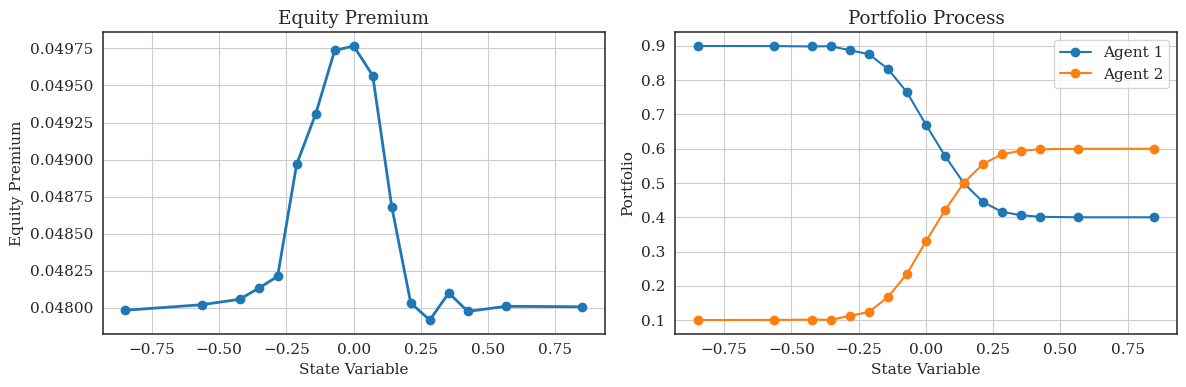

In [134]:
import numpy as np
import matplotlib.pyplot as plt
import torch


# ===============================
# Extract center values
# ===============================

# x_points = []

# premium_points = []
# theta1_points = []
# theta2_points = []

# for c in x_centers:

#     x = results[c]["x"]

#     premium = results[c]["premium"]
#     theta1 = results[c]["theta1"]
#     theta2 = results[c]["theta2"]

#     # 找最接近 x=0 的点
#     idx = torch.argmin(torch.abs(x))

#     x_points.append(c)

#     premium_points.append(premium[idx].item())
#     theta1_points.append(theta1[idx].item())
#     theta2_points.append(theta2[idx].item())


# x_points = np.array(x_points)
# premium_points = np.array(premium_points)
# theta1_points = np.array(theta1_points)
# theta2_points = np.array(theta2_points)


# ===============================
# Rescale X
# ===============================

# x_points = x_points * (0.2 / np.sqrt(2))


# ===============================
# Plot in 1×2 layout
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(12,4))


# ---- Equity Premium ----
# axes[0].plot(x_points, premium_points, 'o-', linewidth=2)
axes[0].plot(x_points, premium_all, 'o-', linewidth=2)
axes[0].set_xlabel("State Variable")
axes[0].set_ylabel("Equity Premium")
axes[0].set_title("Equity Premium")
axes[0].grid(True)


# ---- Portfolio Process ----
# axes[1].plot(x_points, theta1_points, 'o-', label="Agent 1")
# axes[1].plot(x_points, theta2_points, 'o-', label="Agent 2")
axes[1].plot(x_points, theta1_all, 'o-', label="Agent 1")
axes[1].plot(x_points, theta2_all, 'o-', label="Agent 2")

axes[1].set_xlabel("State Variable")
axes[1].set_ylabel("Portfolio")
axes[1].set_title("Portfolio Process")

axes[1].legend()
axes[1].grid(True)


plt.tight_layout()
plt.show()

In [49]:
extra_centers = [-6, -4, 4, 6]

extra_x = []
extra_premium = []
extra_theta1 = []
extra_theta2 = []

for center in extra_centers:

    print(f"training center {center}")

    config['x2'] = center
    config['checkpoint_path'] = f'radner_x{center}.pth'

    solver = RadnerEquilibriumSolver_put(config)
    solver.train(NIter=1000, epoch=10, patience=2)

    device = config['device']

    # 和之前完全一样的 evaluation
    x_local = torch.linspace(-0.25, 0.25, 500).to(device)

    x1_grid = torch.zeros_like(x_local)
    X0 = torch.stack([x1_grid, x_local], dim=1)
    t0 = torch.zeros(len(x_local), 1).to(device)

    with torch.no_grad():

        Y0 = solver.net_y(t0, X0)
        Z0 = solver.net_z(t0, X0)

        for i in range(solver.I + 1):
            Z0[:, i*solver.D:(i+1)*solver.D] = (
                Z0[:, i*solver.D:(i+1)*solver.D].unsqueeze(1)
                @ solver.sig(t0, X0)
            ).squeeze()

        premium = solver.phi0(t0, X0, Z0, solver.epsilon).cpu() / (6/5)

        theta = solver.theta(Y0, Z0, len(x_local))
        theta1 = theta[0].cpu() * solver.alpha[0]
        theta2 = theta[1].cpu() * solver.alpha[1]

    # 取 x_local = 0 的点
    idx = torch.argmin(torch.abs(x_local))

    extra_x.append(center)
    extra_premium.append(premium[idx].item())
    extra_theta1.append(theta1[idx].item())
    extra_theta2.append(theta2[idx].item())

    print(f"center {center} done")

training center -6
Epoch 1
-------------------------------
Loss 200: 0.0013725217431783676, time: 21.49601950000215
Loss 400: 0.00011685822391882539, time: 42.589145124991774
Loss 600: 2.6726265787146986e-05, time: 64.63343637499202
Loss 800: 8.114748197840527e-06, time: 86.53455595800187
Loss 1000: 3.7176371279201703e-06, time: 108.4425000409974
Validation Loss 1: 0.0000
val_loss: 0.0000, updating best_val_loss from: inf.
Epoch 2
-------------------------------
Loss 200: 2.3460338525183033e-06, time: 130.5200841659971
Loss 400: 1.4040952009963803e-06, time: 152.29328958300175
Loss 600: 1.5795334320500842e-06, time: 173.70800462500483
Loss 800: 9.640428970669745e-07, time: 197.76596833299845
Loss 1000: 6.729562755936058e-07, time: 222.1680522079987
Validation Loss 2: 0.0000
val_loss: 0.0000, updating best_val_loss from: 0.0000.
Epoch 3
-------------------------------
Loss 200: 5.388494059843651e-07, time: 243.5176071659953
Loss 400: 5.665652338393556e-07, time: 266.27990087500075
Loss 

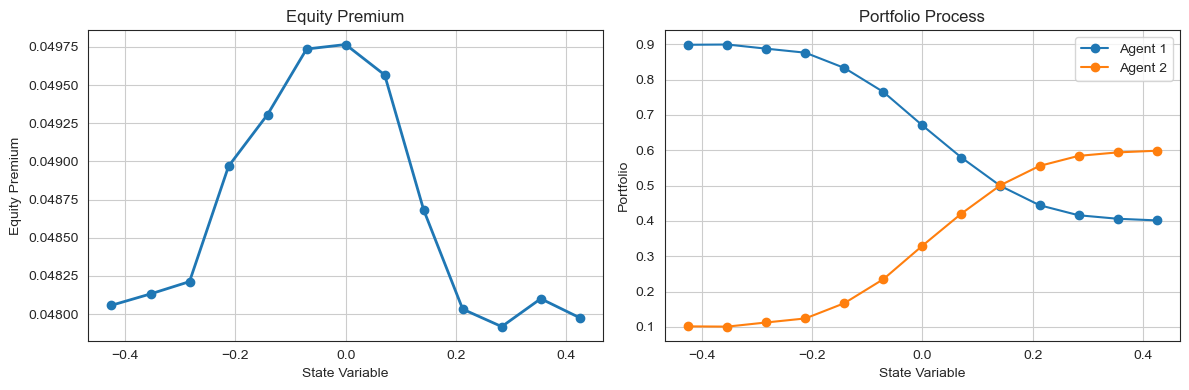

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import torch


# ===============================
# Extract center values
# ===============================

x_points = []

premium_points = []
theta1_points = []
theta2_points = []

for c in x_centers:

    x = results[c]["x"]

    premium = results[c]["premium"]
    theta1 = results[c]["theta1"]
    theta2 = results[c]["theta2"]

    # 找最接近 x=0 的点
    idx = torch.argmin(torch.abs(x))

    x_points.append(c)

    premium_points.append(premium[idx].item())
    theta1_points.append(theta1[idx].item())
    theta2_points.append(theta2[idx].item())


x_points = np.array(x_points)
premium_points = np.array(premium_points)
theta1_points = np.array(theta1_points)
theta2_points = np.array(theta2_points)


# ===============================
# Rescale X
# ===============================

x_points = x_points * (0.2 / np.sqrt(2))


# ===============================
# Plot in 1×2 layout
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(12,4))


# ---- Equity Premium ----
axes[0].plot(x_points, premium_points, 'o-', linewidth=2)
axes[0].set_xlabel("State Variable")
axes[0].set_ylabel("Equity Premium")
axes[0].set_title("Equity Premium")
axes[0].grid(True)


# ---- Portfolio Process ----
axes[1].plot(x_points, theta1_points, 'o-', label="Agent 1")
axes[1].plot(x_points, theta2_points, 'o-', label="Agent 2")

axes[1].set_xlabel("State Variable")
axes[1].set_ylabel("Portfolio")
axes[1].set_title("Portfolio Process")

axes[1].legend()
axes[1].grid(True)


plt.tight_layout()
plt.show()

In [67]:
x_points

array([-0.42426407, -0.35355339, -0.28284271, -0.21213203, -0.14142136,
       -0.07071068,  0.        ,  0.07071068,  0.14142136,  0.21213203,
        0.28284271,  0.35355339,  0.42426407])

In [73]:
extra_x = [-6, -4, 4, 6]

In [74]:
# ===============================
# Merge old points + new points
# ===============================

x_all = np.concatenate([x_points, np.array(extra_x)* (0.2 / np.sqrt(2))])
premium_all = np.concatenate([premium_points, np.array(extra_premium)])
theta1_all = np.concatenate([theta1_points, np.array(extra_theta1)])
theta2_all = np.concatenate([theta2_points, np.array(extra_theta2)])



# ===============================
# Sort by x
# ===============================

idx = np.argsort(x_all)

x_all = x_all[idx]
premium_all = premium_all[idx]
theta1_all = theta1_all[idx]
theta2_all = theta2_all[idx]

In [42]:
# =========================
# 拼接区间
# =========================


x_all = []
premium_all = []
theta1_all = []
theta2_all = []
vol_all = []

for center in x_centers:

    r = results[center]

    x = r["x"]
    premium = r["premium"]
    theta1 = r["theta1"]
    theta2 = r["theta2"]
    vol = r["vol"]

    # # 对重叠区间处理
    # if len(x_all) > 0:
    #     mask = x > x_all[-1]   # 只保留新的部分
    #     x = x[mask]
    #     premium = premium[mask]
    #     theta1 = theta1[mask]
    #     theta2 = theta2[mask]
    #     vol = vol[mask]

    x_all.append(x)
    premium_all.append(premium)
    theta1_all.append(theta1)
    theta2_all.append(theta2)
    vol_all.append(vol)

# 拼接 tensor
x_all = torch.cat(x_all)*(0.2 * np.sqrt(2))
premium_all = torch.cat(premium_all)
theta1_all = torch.cat(theta1_all)
theta2_all = torch.cat(theta2_all)
vol_all = torch.cat(vol_all)

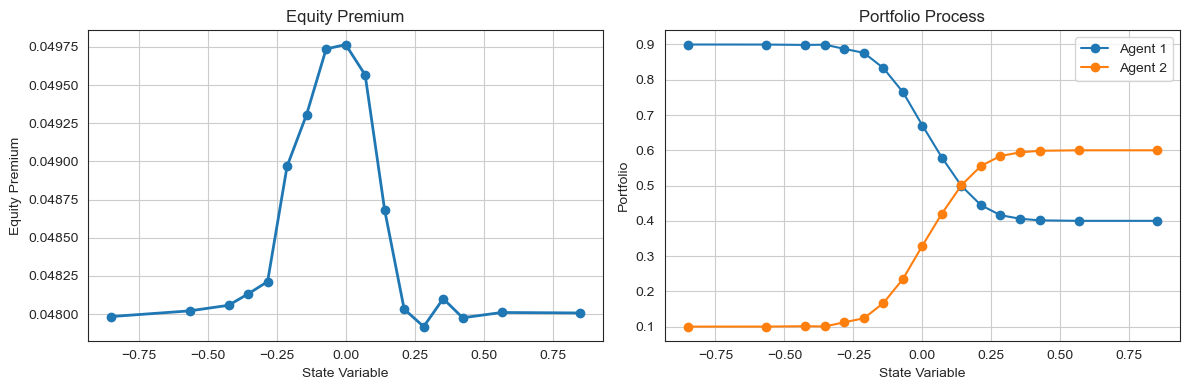

In [75]:
fig, axes = plt.subplots(1,2, figsize=(12,4))


# ===== equity premium =====
axes[0].plot(x_all, premium_all, 'o-', linewidth=2)

axes[0].set_xlabel("State Variable")
axes[0].set_ylabel("Equity Premium")
axes[0].set_title("Equity Premium")
axes[0].grid(True)


# ===== portfolio =====
axes[1].plot(x_all, theta1_all, 'o-', label="Agent 1")
axes[1].plot(x_all, theta2_all, 'o-', label="Agent 2")

axes[1].set_xlabel("State Variable")
axes[1].set_ylabel("Portfolio")
axes[1].set_title("Portfolio Process")

axes[1].legend()
axes[1].grid(True)


plt.tight_layout()
plt.show()

In [93]:
import pandas as pd

df = pd.DataFrame({
    "x": x_all,
    "premium": premium_all,
    "theta1": theta1_all,
    "theta2": theta2_all
})

df.to_csv("/Users/sokchak/Desktop/FBSDE_NN/radner_equilibrium_solver/radner_equilibrium_terminal_dl/radner_solver_terminal/radner_results1.0.csv", index=False)

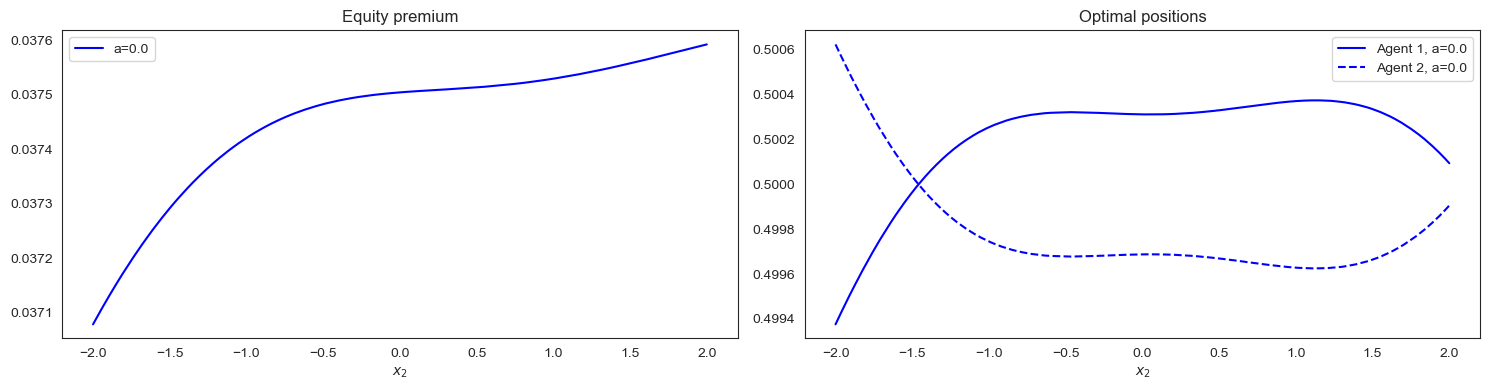

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for a, color in zip(a_values, colors):
    r = results[a]
    x2 = r['x2_grid']
    label = f"a={a}"
    
    axes[0].plot(x2, r['equity_premium'], color=color, label=label)
    # axes[1].plot(x2, r['volatility'],     color=color, label=label)
    axes[1].plot(x2, r['theta1'], color=color, linestyle='-',  label=f"Agent 1, a={a}")
    axes[1].plot(x2, r['theta2'], color=color, linestyle='--', label=f"Agent 2, a={a}")

axes[0].set_title("Equity premium")
axes[0].set_xlabel("$x_2$")
axes[0].legend()

# axes[1].set_title("Total volatility")
# axes[1].set_xlabel("$x_2$")
# axes[1].legend()

axes[1].set_title("Optimal positions")
axes[1].set_xlabel("$x_2$")
axes[1].legend()

plt.tight_layout()
plt.savefig('radner_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
sym_error = theta1 + torch.flip(theta2, dims=[0])
print(sym_error.abs().mean())

tensor(1.)


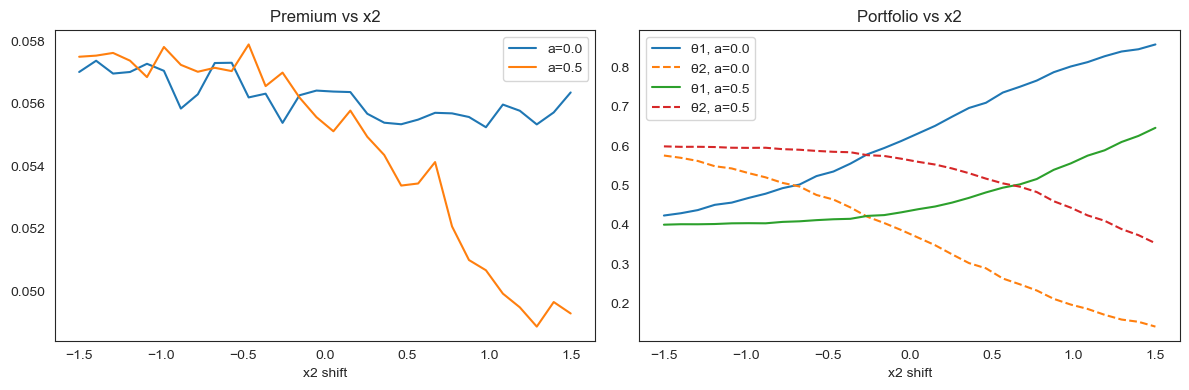

In [2]:
a_values = [0.0, 0.5]
plt.figure(figsize=(12,4))

# ---- premium ----
plt.subplot(1,2,1)
for a in a_values:
    plt.plot(results[a]["x2"], results[a]["premium"], label=f"a={a}")
plt.title("Premium vs x2")
plt.xlabel("x2 shift")
plt.legend()

# ---- theta ----
plt.subplot(1,2,2)
for a in a_values:
    plt.plot(results[a]["x2"], results[a]["theta1"], linestyle='-', label=f"θ1, a={a}")
    plt.plot(results[a]["x2"], results[a]["theta2"], linestyle='--', label=f"θ2, a={a}")

plt.title("Portfolio vs x2")
plt.xlabel("x2 shift")
plt.legend()

plt.tight_layout()
plt.show()

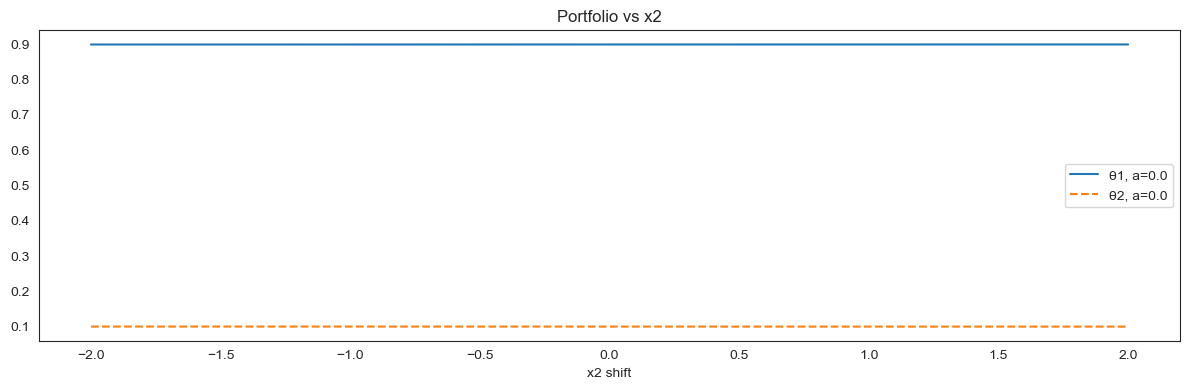

In [4]:
a_values = [0.0]
plt.figure(figsize=(12,4))

# # ---- premium ----
# plt.subplot(1,2,1)
# for a in a_values:
#     plt.plot(results[a]["x2"], results[a]["premium"], label=f"a={a}")
# plt.title("Premium vs x2")
# plt.xlabel("x2 shift")
# plt.legend()

# ---- theta ----
plt.subplot(1,1,1)
for a in a_values:
    plt.plot(results[a]["x2"], results[a]["theta1"], linestyle='-', label=f"θ1, a={a}")
    plt.plot(results[a]["x2"], results[a]["theta2"], linestyle='--', label=f"θ2, a={a}")

plt.title("Portfolio vs x2")
plt.xlabel("x2 shift")
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
print('Agent 1 theta:')
print('x2 = -2:', results[a]["theta1"][0])
print('x2 =  2:', results[a]["theta1"][1])

print('Agent 2 theta:')
print('x2 = -2:', results[a]["theta2"][0])
print('x2 =  2:', results[a]["theta2"][1])

Agent 1 theta:
x2 = -2: 0.8998456001281738
x2 =  2: 0.9000154733657837
Agent 2 theta:
x2 = -2: 0.10015440732240677
x2 =  2: 0.09998460114002228


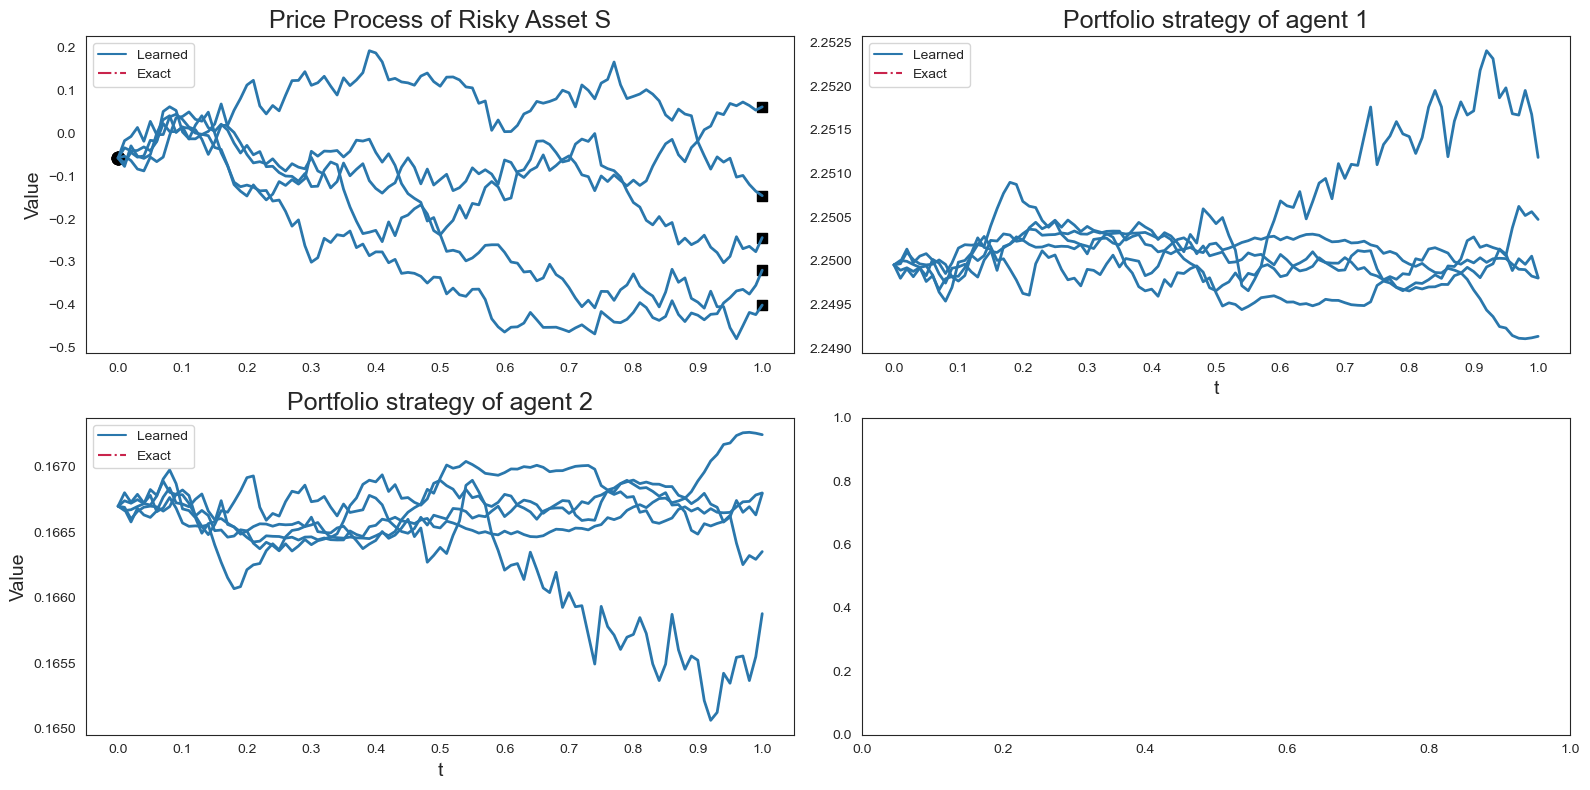

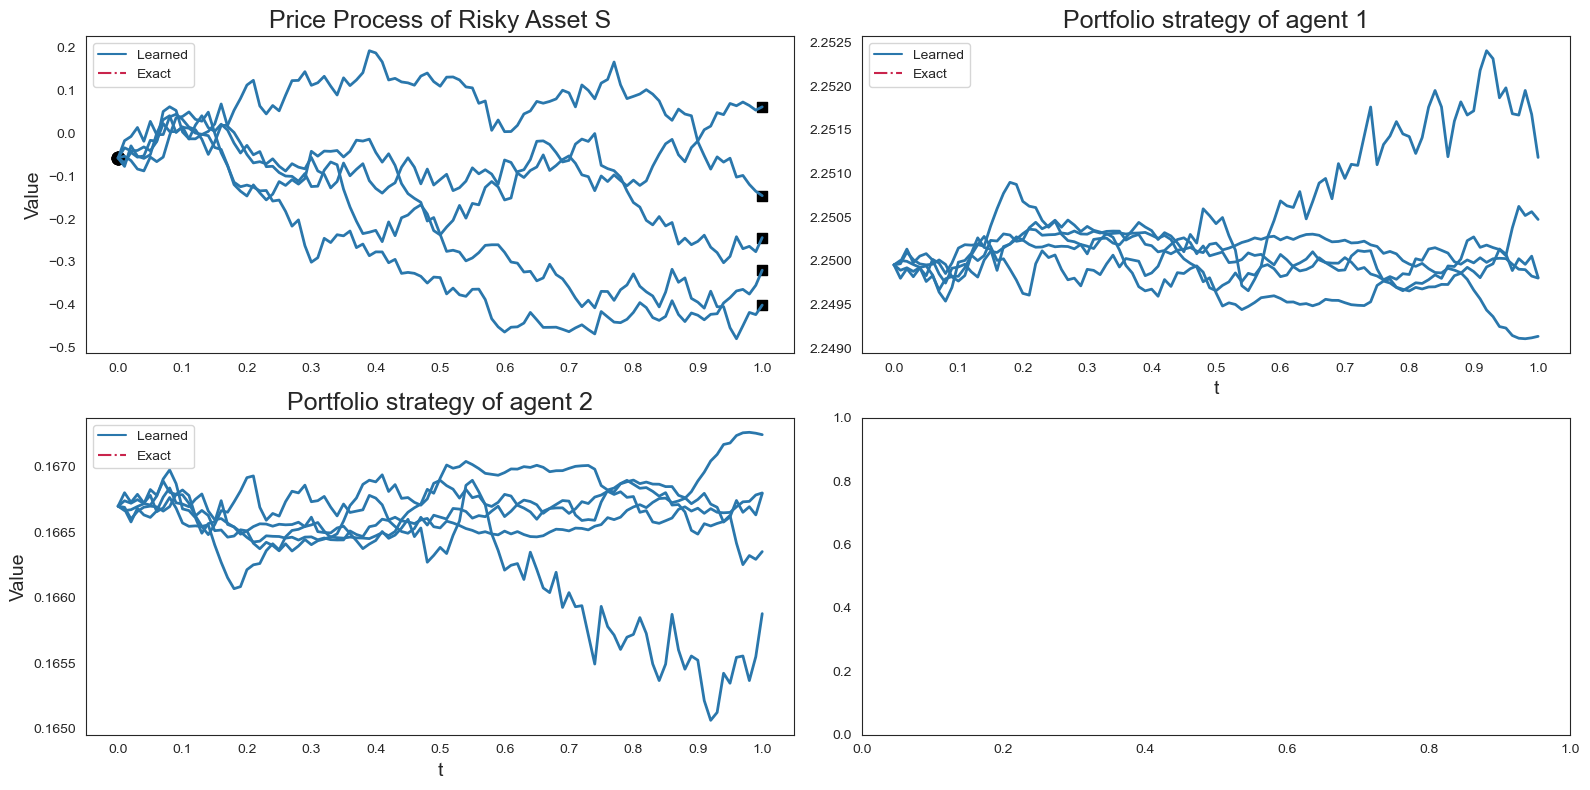

In [3]:
t, W = BrownianMotionGenerator.generate(solver.K, solver.N, solver.D, solver.T)

Y_path, theta_path = solver.predict(t, W)

# -------------------------
# 5. Visualization
# -------------------------


viz = RadnerVisualizer()

# Plot predicted 

viz.plot_price_and_theta_pred(
    Y_path,
    theta_path,
    save_path="/Users/sokchak/Desktop/FBSDE_NN/radner_equilibrium_solver/radner_equilibrium_terminal_dl/radner_solver_terminal/pic/theta_path.pdf",
)


min ζ: tensor(0.1648)
max ζ: tensor(0.1714)


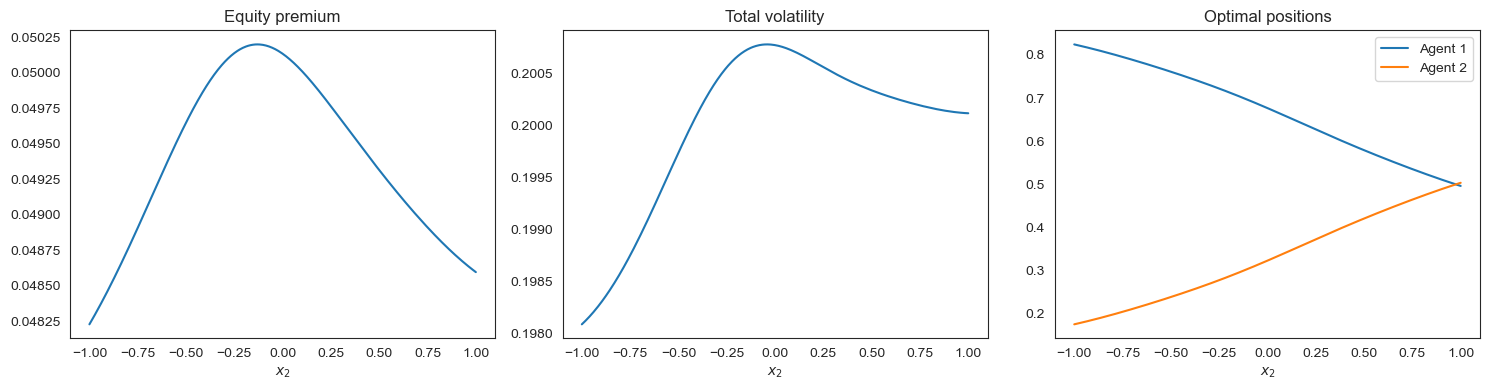

In [21]:
import matplotlib.pyplot as plt

device = solver.device

x2_grid = torch.linspace(-1.0, 1.0, 500).to(device)

x1_grid = torch.zeros_like(x2_grid)

X0 = torch.stack([x1_grid, x2_grid], dim=1)

t0 = torch.zeros(len(x2_grid),1).to(device)

with torch.no_grad():

    Y0 = solver.net_y(t0, X0)

    Z0 = solver.net_z(t0, X0)
    for i in range(solver.I+1):
        Z0[:, i*solver.D:(i+1)*solver.D] = (
            Z0[:, i*solver.D:(i+1)*solver.D].unsqueeze(1)
            @ solver.sig(t0, X0)
        ).squeeze()
    zeta = Z0[:, :solver.D]

    print("min ζ:", torch.min(zeta))
    print("max ζ:", torch.max(zeta))

    equity_premium = solver.phi0(t0, X0, Z0, solver.epsilon).cpu()/(6/5)

    volatility = torch.norm(Z0[:,:solver.D], dim=1).cpu()/(6/5)

    theta = solver.theta(Y0, Z0, len(x2_grid))

    theta1 = theta[0].cpu() * solver.alpha[0]
    theta2 = theta[1].cpu() * solver.alpha[1]

x2_grid = x2_grid.cpu()

plt.figure(figsize=(15,4))

# Equity premium
plt.subplot(1,3,1)
plt.plot(x2_grid, equity_premium)
plt.title("Equity premium")
plt.xlabel("$x_2$")

# Volatility
plt.subplot(1,3,2)
plt.plot(x2_grid, volatility)
plt.title("Total volatility")
plt.xlabel("$x_2$")

# Positions
plt.subplot(1,3,3)
plt.plot(x2_grid, theta1, label="Agent 1")
plt.plot(x2_grid, theta2, label="Agent 2")
plt.title("Optimal positions")
plt.xlabel("$x_2$")
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
# -*- coding: utf-8 -*-
import torch
import numpy as np
import matplotlib.pyplot as plt
from core.data_generator import BrownianMotionGenerator
from core.network import FeedForwardNN as myNN
from models.radner_terminal_general_solver import RadnerEquilibriumSolver4, RadnerEquilibriumSolver_NoPhi1
from utils.visualization import RadnerVisualizer


import copy
import os
import random

def set_seed(seed=1000):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # deterministic mode
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # 强制使用 deterministic 算法
    torch.use_deterministic_algorithms(True)

    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

set_seed(100)

# -------------------------
# 1. Benchmark Nonlinear Economy: Example 4.4
# -------------------------

# Time horizon and discretization
T = 1  # Terminal time
M = 128  # Number of trajectories per batch
N = 50 # Number of time steps
D = 2  # Dimension of Brownian motion (state space)
I = 2  # Number of agents
K = 1000  # Number of validation trajectories


# Training hyperparameters
epoch = 10 # Number of training epochs
NIter = 1000  # Number of iterations per epoch
patience = 2  # Patience for early stopping


t_train, W_train = BrownianMotionGenerator.generate(M * NIter, N, D, T)

config = {
    'T': T,
    'M': M,
    'N': N,
    'D': D,
    'I': I,
    'K': K,
    'learning_rate': 1e-4,
    'device': 'cpu',
    # 'layers': [D + 1] + 5 * [256] + [(I + 1) * (1 + D)],  #NN layers
    'layers_z': [D + 1] + 5 * [256] + [(I + 1) * (D)],  #NN layers
    'layers_y': [D + 1] + 5 * [256] + [(I + 1) * 1],  #NN layers
    'drift_D': 0.0,
    'sigD': torch.tensor([[0.24/np.sqrt(2), 0.24/np.sqrt(2)]], dtype=torch.float32),  # dividend depends on W1+W2
    'muE': torch.zeros(2),
    'sigE': torch.tensor([
        [0., 0.6/np.sqrt(2)],  # Agent1 exposure to W2 (put)
        [0., 0.4/np.sqrt(2)]   # Agent2 opposite
    ], dtype=torch.float32),
    'alpha': torch.tensor([0.4, 0.6]),  # CARA risk aversion
    'epsilon': 1e-6,
    'N_option': 1,  # Number of options in the economy (for payoff construction),
    'a_expo': 1,  # Exponent for payoff construction (e.g., power utility)
    'x2': -3.0,  # Coefficient for W2 in payoff construction
    'checkpoint_path': 'radner_example44.pth',
    't_train': t_train,  # To be set after generating training data
    'W_train': W_train,  # To be set after generating training data
}


class RadnerEquilibriumSolver_put(RadnerEquilibriumSolver4):
    def __init__(self, config):
        """Initialize solver with configuration dictionary.
        
        Args:
            config: Dictionary containing:
                - T: Terminal time
                - M: Batch size (number of trajectories)
                - N: Number of time steps
                - D: State dimension
                - I: Number of agents
                - K: Validation set size
                - learning_rate: Learning rate for Adam
                - device: 'cpu' or 'cuda'
                - checkpoint_path: Path to save best model
        """
        super().__init__(config)
        self.x2 = config['x2']
        
    

    def endowment_process(self, t, X, i):

        

        N_option = self.N_option
        k = self.a_expo
        x2 = self.x2

        temp = self.sigE[i,:] * (X + x2)
        # return torch.sum(temp, -1, keepdim = True)

        X2 = temp[:,1:2]  # second Brownian source
    
        # put_payoff = F.softplus(-X2, beta=50.0)
        # call_payoff = torch.clamp(X2 - k, min=0.0)
        # call_payoff = X2
        call_payoff = torch.minimum(X2, torch.zeros_like(X2))

        if i == 0:

            return -N_option * call_payoff

        else:

            return N_option * call_payoff
# torch.manual_seed(1000)
# solver1 = RadnerEquilibriumSolver4(config)
# params_init_1 = copy.deepcopy(solver1.model_z.state_dict())

# torch.manual_seed(1000)
# solver2 = RadnerEquilibriumSolver4(config)
# params_init_2 = copy.deepcopy(solver2.model_z.state_dict())

# for k in params_init_1:
#     print(torch.allclose(params_init_1[k], params_init_2[k]))

print("\nProblem Configuration:")
print(f"  Terminal time: {config['T']}")
print(f"  State dimension: {config['D']}")
print(f"  Number of agents: {config['I']}")
print(f"  Time steps: {config['N']}")
print(f"  Batch size: {config['M']}")
# print(f"  Network architecture: {config['layers_y']} and {config['layers_z']}")
# print(f"  Network architecture: {config['layers']}")

# Initialize solver
print("\nInitializing solver...")
# solver = RadnerEquilibriumSolver_NoPhi1(config)
solver = RadnerEquilibriumSolver_put(config)

print("\nStarting training...")
solver.train(NIter, epoch, patience)     


# Print training summary
print("\n" + "="*60)
print("Training Summary:")
print("="*60)
print(f"Best epoch: {solver.history['best_epoch'] + 1}")
print(f"Best validation loss: {solver.history['best_val_loss']:.6f}")
print(f"Final training loss: {solver.history['train_loss'][-1]:.6f}")
print(f"Total training time: {solver.history['train_time']:.2f} seconds")
print(f"Average time per epoch: {solver.history['time_per_epoch']:.2f} seconds")



# import matplotlib.pyplot as plt
# import torch

# x_centers = [-3, -2.5, -2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5, 3]
# colors = ['blue', 'green', 'orange', 'red', 'purple']

# results = {}

# results = {}

# for center in x_centers:

#     config['x2'] = center
#     config['checkpoint_path'] = f'radner_x{center}.pth'

#     solver = RadnerEquilibriumSolver_put(config)
#     solver.train(NIter=1000, epoch=10, patience=2)

#     device = config['device']

#     # 每个模型只算 ±2
#     x_local = torch.linspace(center - 0.25, center + 0.25, 500).to(device)

#     x1_grid = torch.zeros_like(x_local)
#     X0 = torch.stack([x1_grid, x_local], dim=1)
#     t0 = torch.zeros(len(x_local), 1).to(device)

#     with torch.no_grad():

#         Y0 = solver.net_y(t0, X0)
#         Z0 = solver.net_z(t0, X0)

#         for i in range(solver.I + 1):
#             Z0[:, i*solver.D:(i+1)*solver.D] = (
#                 Z0[:, i*solver.D:(i+1)*solver.D].unsqueeze(1)
#                 @ solver.sig(t0, X0)
#             ).squeeze()

#         equity_premium = solver.phi0(t0, X0, Z0, solver.epsilon).cpu() / (6/5)

#         theta = solver.theta(Y0, Z0, len(x_local))
#         theta1 = theta[0].cpu() * solver.alpha[0]
#         theta2 = theta[1].cpu() * solver.alpha[1]

#         volatility = torch.norm(Z0[:, :solver.D], dim=1, keepdim=True).cpu() / (6/5)

#     results[center] = {
#         "x": x_local.cpu(),
#         "premium": equity_premium,
#         "theta1": theta1,
#         "theta2": theta2,
#         "vol": volatility
#     }

#     print(f"center {center} done")


Problem Configuration:
  Terminal time: 1
  State dimension: 2
  Number of agents: 2
  Time steps: 50
  Batch size: 128

Initializing solver...

Starting training...
Epoch 1
-------------------------------
Loss 200: 0.00011945943697355688, time: 19.903311834001215
Loss 400: 9.48020624491619e-06, time: 39.66595799999777
Loss 600: 6.0362049225659575e-06, time: 59.55626954200852
Loss 800: 2.179936245738645e-06, time: 79.71155845900648
Loss 1000: 1.6229108950938098e-05, time: 99.89009466700372
Validation Loss 1: 0.0000
val_loss: 0.0000, updating best_val_loss from: inf.
Epoch 2
-------------------------------
Loss 200: 1.0005947842728347e-05, time: 120.94271554199804
Loss 400: 1.693203216746042e-06, time: 141.21899249999842
Loss 600: 2.729711923166178e-06, time: 161.654792041998
Loss 800: 1.4922776472303667e-06, time: 182.21554037500755
Loss 1000: 1.2313813613218372e-06, time: 202.75818866700865
Validation Loss 2: 0.0000
val_loss: 0.0000, updating best_val_loss from: 0.0000.
Epoch 3
-----

/Users/sokchak/Desktop/FBSDE_NN/radner_equilibrium_solver/radner_equilibrium_terminal_dl/radner_solver_terminal/models/radner_terminal_general_solver.py:937: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related t

min ζ: tensor(0.1695)
max ζ: tensor(0.1701)


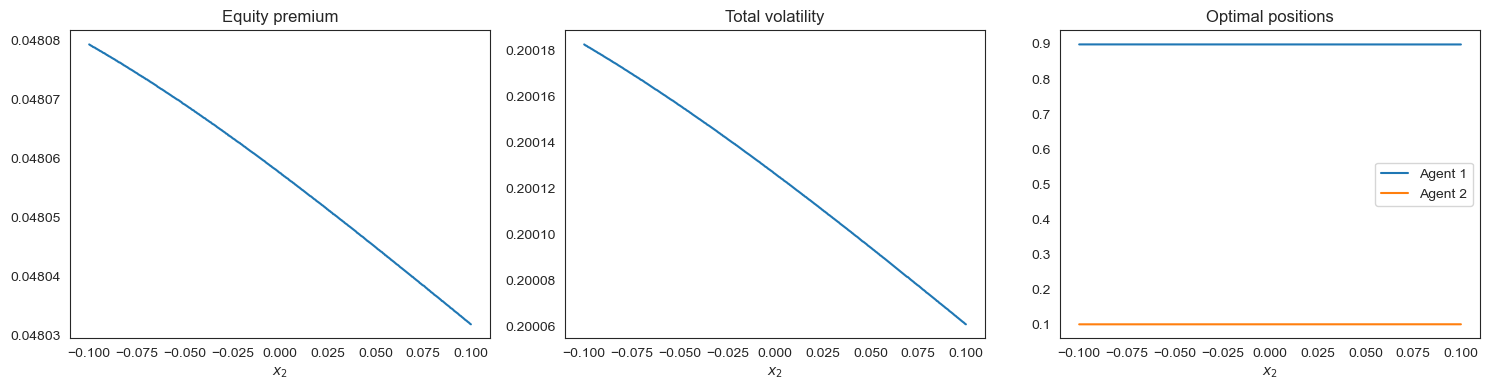

In [31]:
import matplotlib.pyplot as plt

device = solver.device

x2_grid = torch.linspace(-0.1, 0.1, 500).to(device)

x1_grid = torch.zeros_like(x2_grid)

X0 = torch.stack([x1_grid, x2_grid], dim=1)

t0 = torch.zeros(len(x2_grid),1).to(device)

with torch.no_grad():

    Y0 = solver.net_y(t0, X0)

    Z0 = solver.net_z(t0, X0)
    for i in range(solver.I+1):
        Z0[:, i*solver.D:(i+1)*solver.D] = (
            Z0[:, i*solver.D:(i+1)*solver.D].unsqueeze(1)
            @ solver.sig(t0, X0)
        ).squeeze()
    zeta = Z0[:, :solver.D]

    print("min ζ:", torch.min(zeta))
    print("max ζ:", torch.max(zeta))

    equity_premium = solver.phi0(t0, X0, Z0, solver.epsilon).cpu()/(6/5)

    volatility = torch.norm(Z0[:,:solver.D], dim=1).cpu()/(6/5)

    theta = solver.theta(Y0, Z0, len(x2_grid))

    theta1 = theta[0].cpu() * solver.alpha[0]
    theta2 = theta[1].cpu() * solver.alpha[1]

x2_grid = x2_grid.cpu()

plt.figure(figsize=(15,4))

# Equity premium
plt.subplot(1,3,1)
plt.plot(x2_grid, equity_premium)
plt.title("Equity premium")
plt.xlabel("$x_2$")

# Volatility
plt.subplot(1,3,2)
plt.plot(x2_grid, volatility)
plt.title("Total volatility")
plt.xlabel("$x_2$")

# Positions
plt.subplot(1,3,3)
plt.plot(x2_grid, theta1, label="Agent 1")
plt.plot(x2_grid, theta2, label="Agent 2")
plt.title("Optimal positions")
plt.xlabel("$x_2$")
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
def plot_theta_vs_weather(
    solver,
    t_fixed=0.5,
    W1_fixed=0.0,
    save_path=None,
):
    W2, _, theta_vals = evaluate_on_weather_grid(
        solver,
        t_fixed=t_fixed,
        W1_fixed=W1_fixed,
    )

    I = solver.I

    plt.figure(figsize=(6, 4))
    for i in range(I):
        plt.plot(
            W2,
            theta_vals[i],
            linewidth=3,
            label=rf"Agent {i+1}",
        )

    plt.axvline(0.0, color="gray", linestyle="--", alpha=0.7)
    plt.xlabel(r"Weather shock $W_2$", fontsize=14)
    plt.ylabel(r"Portfolio $\theta$", fontsize=14)
    plt.title(rf"Portfolio strategies at $t={t_fixed}$", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

In [1]:
import pickle
with open('/Users/sokchak/Desktop/FBSDE_NN/radner_equilibrium_solver/radner_equilibrium_terminal_dl/radner_solver_terminal/data/model1/loss_records.pkl', 'rb') as f:
    loss_records = pickle.load(f)



In [8]:
def plot_loss_decay_MN(loss_records, save_path=None, step=200):

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ======================
    # Left: training loss
    # ======================
    for (M_, N_), hist in loss_records.items():

        loss = np.array(hist['train_loss'])

        idx = np.arange(0, len(loss), step)

        axes[0].plot(
            idx,
            loss[idx],
            linewidth=2,
            label=f"M={M_}, N={N_}",
        )

    axes[0].set_yscale("log")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Training loss (log scale)")
    axes[0].set_title("Loss decay for different $(M,N)$")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    # ======================
    # middle: validation L2 error
    # ======================
    for (M_, N_), hist in loss_records.items():

        error = np.array(hist['valid_error'])

        idx = np.arange(0, len(error), step)

        axes[1].plot(
            idx,
            error[idx],
            linewidth=2,
            label=f"M={M_}, N={N_}",
        )

    axes[1].set_yscale("log")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Validation error (log scale)")
    axes[1].set_title("L2 Error decay for different $(M,N)$")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    # ======================
    # Right: Validation Y0 error
    # ======================
    for (M_, N_), hist in loss_records.items():

        error = np.array(hist['Y0_error'])

        idx = np.arange(0, len(error), step)

        axes[2].plot(
            idx,
            error[idx],
            linewidth=2,
            label=f"M={M_}, N={N_}",
        )

    axes[2].set_yscale("log")
    axes[2].set_xlabel("Iteration")
    axes[2].set_ylabel("Validation error (log scale)")
    axes[2].set_title("Y0 Error decay for different $(M,N)$")
    axes[2].grid(alpha=0.3)
    axes[2].legend()

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

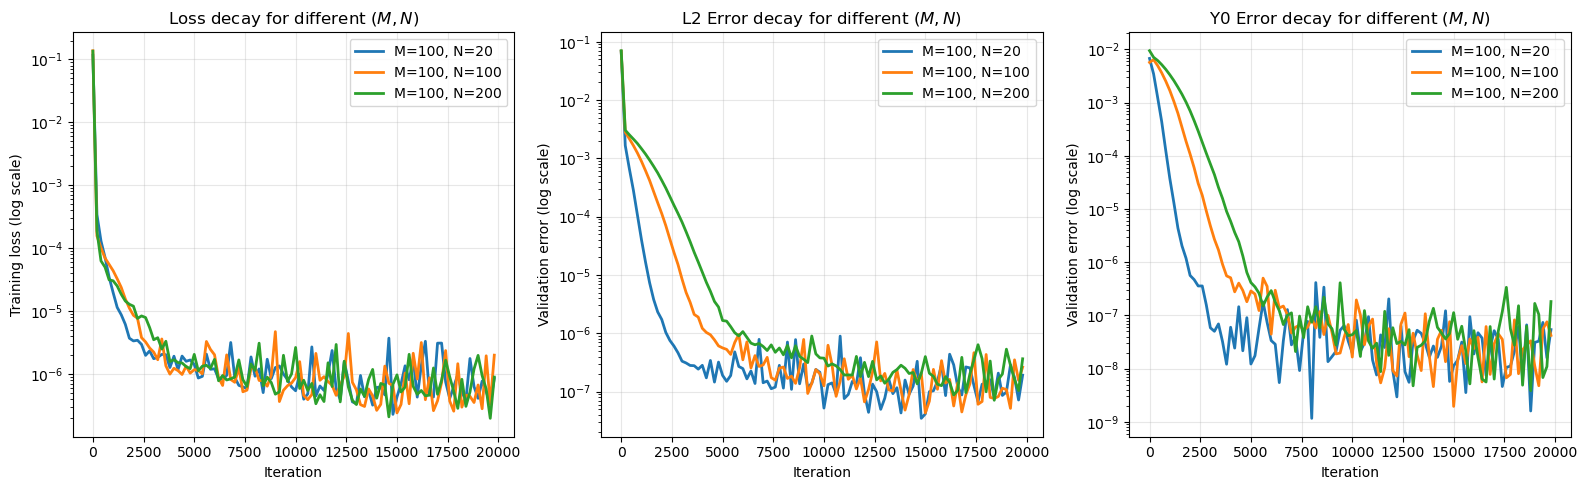

In [9]:
plot_loss_decay_MN(loss_records, step=200)

In [4]:
import numpy as np
import matplotlib.pyplot as plt


# =====================================================
# smoothing function (journal-quality block averaging)
# =====================================================

def smooth_curve(x, step=200):
    """
    Smooth curve using block averaging.

    Parameters
    ----------
    x : array-like
        original noisy sequence

    step : int
        block size for averaging

    Returns
    -------
    x_smooth : np.ndarray
    """

    x = np.array(x)

    if len(x) < step:
        return x

    n_block = len(x) // step

    x = x[:n_block * step]

    x_smooth = x.reshape(n_block, step).mean(axis=1)

    return x_smooth


# =====================================================
# main plotting function
# =====================================================

def plot_loss_decay_MN(loss_records, save_path=None, step=200):
    """
    Journal-quality loss decay plot with smoothing.

    Parameters
    ----------
    loss_records : dict
        loss_records[(M, N)] = {
            'train_loss': list,
            'valid_error': list,
            'Y0_error': list
        }

    save_path : str or None

    step : int
        smoothing window (recommended: 100–500)
    """

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # =====================================================
    # 1. training loss
    # =====================================================

    for (M_, N_), hist in loss_records.items():

        loss = smooth_curve(hist['train_loss'], step)

        iterations = np.arange(len(loss)) * step

        axes[0].plot(
            iterations,
            loss,
            linewidth=2.5,
            label=f"M={M_}, N={N_}",
        )

    axes[0].set_yscale("log")

    axes[0].set_xlabel("Iteration", fontsize=13)

    axes[0].set_ylabel("Training loss", fontsize=13)

    axes[0].set_title("Training loss decay", fontsize=14)

    axes[0].grid(alpha=0.3)

    axes[0].legend(fontsize=11)


    # =====================================================
    # 2. validation L2 error
    # =====================================================

    for (M_, N_), hist in loss_records.items():

        error = smooth_curve(hist['valid_error'], step)

        iterations = np.arange(len(error)) * step

        axes[1].plot(
            iterations,
            error,
            linewidth=2.5,
            label=f"M={M_}, N={N_}",
        )

    axes[1].set_yscale("log")

    axes[1].set_xlabel("Iteration", fontsize=13)

    axes[1].set_ylabel(r"$\mathcal{E}_2(\mathbf{U})$", fontsize=13)

    axes[1].set_title("Validation L2 error decay", fontsize=14)

    axes[1].grid(alpha=0.3)

    axes[1].legend(fontsize=11)


    # =====================================================
    # 3. Y0 error
    # =====================================================

    for (M_, N_), hist in loss_records.items():

        error = smooth_curve(hist['Y0_error'], step)

        iterations = np.arange(len(error)) * step

        axes[2].plot(
            iterations,
            error,
            linewidth=2.5,
            label=f"M={M_}, N={N_}",
        )

    axes[2].set_yscale("log")

    axes[2].set_xlabel("Iteration", fontsize=13)

    axes[2].set_ylabel(r"$|U(0,X_0)-Y_0|^2$", fontsize=13)

    axes[2].set_title("Initial value error decay", fontsize=14)

    axes[2].grid(alpha=0.3)

    axes[2].legend(fontsize=11)


    # =====================================================
    # layout
    # =====================================================

    plt.tight_layout()

    if save_path is not None:

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

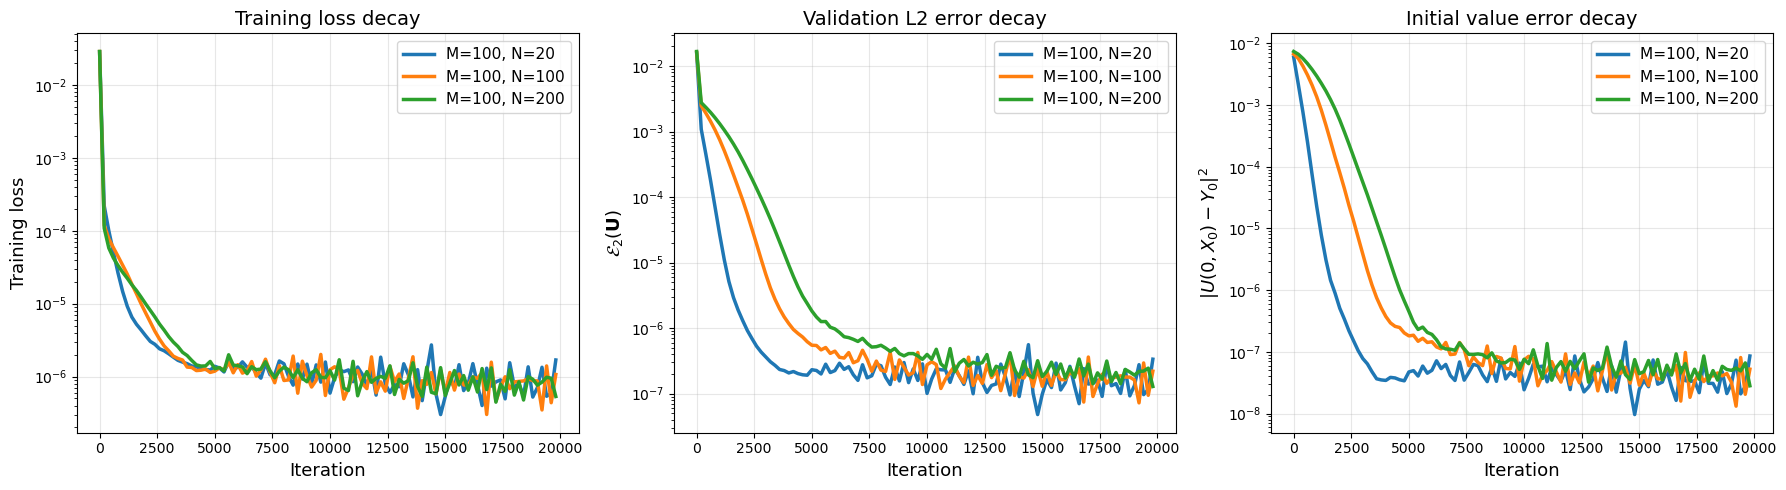

In [5]:
plot_loss_decay_MN(
    loss_records,
    save_path="loss_decay.pdf",
    step=200,
)